# QEC Plot Notebook

This notebook is used to generate the main tables and figures for the paper from the simulation logs.

The four main experiment groups are:

1. Gate-fidelity sweep
   This compares `none`, `cec`, and `qec` while sweeping two-qubit gate fidelity, with one-qubit and measurement fidelity scaled accordingly. The goal is to identify the practical gate-fidelity threshold for each correction method.

2. Coherence-time sweep
   This compares `none`, `cec`, and `qec` while sweeping memory coherence time. The goal is to see how strongly each method depends on memory quality and where each approach begins to fail.

3. End-to-end distance sweep
   This keeps the elementary-link distance fixed at `10 km` and increases the total communication distance. The goal is to measure both latency and end-to-end fidelity as distance grows.

4. Link-count sweep
   This varies the number of links in the chain while keeping the elementary-link distance fixed at `10 km`. The goal is to study how end-to-end fidelity changes as the number of hops increases.


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


## Parse Logs

These regex patterns parse the log filenames and result lines.


In [2]:
line_re = re.compile(
    r"run_id=(?P<run_id>\d+), time to serve=(?P<latency>[-+0-9.eE]+), fidelity=(?P<fidelity>[-+0-9.eE]+)"
)

filename_re = re.compile(
    r"line_(?P<nodes>\d+)_2G,"
    r"code=(?P<code>\[\[.*?\]\]),"
    r"dist=(?P<dist>[0-9.]+),"
    r"gate=(?P<gate>[0-9.]+),"
    r"twoq=(?P<twoq>[0-9.]+),"
    r"prep=(?P<prep>[0-9.]+),"
    r"T1=(?P<t1>[0-9.eE+-]+),"
    r"T2=(?P<t2>[0-9.eE+-]+),"
    r"ft=(?P<ft>[a-zA-Z0-9_]+),"
    r"pauli=(?P<pauli>[0-9._]+|cfg),"
    r"ccorr=(?P<ccorr>none|cec|qec\+cec|qec),"
    r"ts=(?P<ts>\d{8}_\d{4})"
)

## Load Data

This function loads one log directory into a pandas dataframe.


In [3]:
def load_runner_logs(log_dir: Path) -> pd.DataFrame:
    """Load one runner log directory into a flat dataframe.

    Args:
        log_dir: Directory containing runner log files.

    Returns:
        pd.DataFrame: One row per completed run.
    """
    rows = []
    for path in sorted(log_dir.iterdir()):
        if not path.is_file() or path.stat().st_size == 0:
            continue
        filename_match = filename_re.search(path.name)
        if filename_match is None:
            continue

        meta = filename_match.groupdict()
        log_mtime = path.stat().st_mtime
        nodes = int(meta["nodes"])
        num_links = nodes - 1
        elementary_link_km = float(meta["dist"])
        total_distance_km = num_links * elementary_link_km
        t2_value = float(meta["t2"])

        with path.open("r", encoding="utf-8") as file:
            for line in file:
                line_match = line_re.search(line)
                if line_match is None:
                    continue
                rows.append({
                    "log_name": path.name,
                    "log_mtime": log_mtime,
                    "nodes": nodes,
                    "num_links": num_links,
                    "elementary_link_km": elementary_link_km,
                    "total_distance_km": total_distance_km,
                    "css_code": meta["code"],
                    "two_qubit_gate_fidelity": float(meta["twoq"]),
                    "gate_fidelity": float(meta["gate"]),
                    "state_preparation_fidelity": float(meta["prep"]),
                    "data_t2": t2_value,
                    "comm_t2": t2_value,
                    "t1": float(meta["t1"]),
                    "correction_mode": meta["ccorr"],
                    "ft_prep_mode": meta["ft"],
                    "run_id": int(line_match["run_id"]),
                    "latency_ms": float(line_match["latency"]),
                    "fidelity": float(line_match["fidelity"]),
                })
    return pd.DataFrame(rows)


# Experiments


In [4]:
run_after = pd.Timestamp("2026-04-09 00:00:00")  # Set to pd.Timestamp("2026-04-09 00:00:00") to ignore older logs.

# TODO: Do not use this since logging should just override 


In [5]:
output_dir = Path("/Users/patange/Documents/Argonne/QEC/plot_pngs")
output_dir.mkdir(parents=True, exist_ok=True)


## Qubit Overhead Table

Show total qubit overhead as a function of correction mode, FT preparation mode, and the number of nodes `n`.


In [6]:
n = 11  # Number of nodes in the linear chain.

qec_ancillas_by_mode = {"none": 0, "cec": 0, "qec": 3}
ft_ancillas_by_mode = {"none": 0, "minimal": 1, "standard": 4}

rows = []
for correction_mode, qec_ancillas in qec_ancillas_by_mode.items():
    for ft_prep_mode, ft_ancillas in ft_ancillas_by_mode.items():
        ancillas_per_end = max(qec_ancillas, ft_ancillas)
        comm_qubits_per_end = 7
        data_qubits_per_end = 7
        qubits_per_end = comm_qubits_per_end + data_qubits_per_end + ancillas_per_end
        total_qubits = 2 * (n - 1) * qubits_per_end
        rows.append({
            "n": n,
            "correction_mode": correction_mode,
            "ft_prep_mode": ft_prep_mode,
            "comm_qubits_per_end": comm_qubits_per_end,
            "data_qubits_per_end": data_qubits_per_end,
            "reserved_ancillas_per_end": ancillas_per_end,
            "qubits_per_end": qubits_per_end,
            "total_qubits": total_qubits,
        })

pd.DataFrame(rows).sort_values(["correction_mode", "ft_prep_mode"]).reset_index(drop=True)


,n,correction_mode,ft_prep_mode,comm_qubits_per_end,data_qubits_per_end,reserved_ancillas_per_end,qubits_per_end,total_qubits
0,11,cec,minimal,7,7,1,15,300
1,11,cec,none,7,7,0,14,280
2,11,cec,standard,7,7,4,18,360
3,11,none,minimal,7,7,1,15,300
4,11,none,none,7,7,0,14,280
5,11,none,standard,7,7,4,18,360
6,11,qec,minimal,7,7,3,17,340
7,11,qec,none,7,7,3,17,340
8,11,qec,standard,7,7,4,18,360


## Graph 1: Gate-Fidelity Sweep

Plot end-to-end fidelity versus two-qubit gate fidelity for `none`, `cec`, and `qec`.


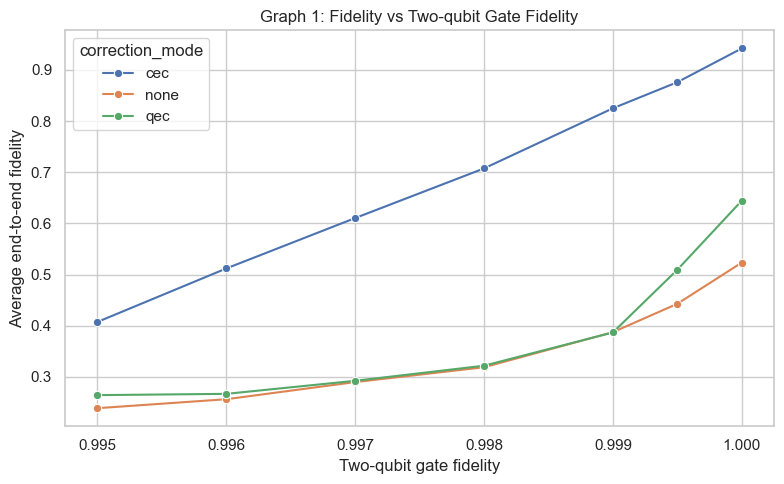

In [7]:
graph1_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph1_twoqubit_gate_sweep")
graph1_df = load_runner_logs(graph1_log_dir)

if run_after is not None and not graph1_df.empty:
    graph1_df = graph1_df[graph1_df["log_mtime"] >= run_after.timestamp()]

if graph1_df.empty:
    print("No Graph 1 data found.")
else:
    graph1_summary = graph1_df.groupby(["two_qubit_gate_fidelity", "correction_mode"], as_index=False).agg(
        mean_fidelity=("fidelity", "mean"),
    ).sort_values(["two_qubit_gate_fidelity", "correction_mode"]).reset_index(drop=True)

    plt.figure(figsize=(8, 5))
    sns.lineplot(data=graph1_summary, x="two_qubit_gate_fidelity", y="mean_fidelity", hue="correction_mode", marker="o")
    plt.xlabel("Two-qubit gate fidelity")
    plt.ylabel("Average end-to-end fidelity")
    plt.title("Graph 1: Fidelity vs Two-qubit Gate Fidelity")
    plt.tight_layout()
    plt.savefig(output_dir / "graph1.png", dpi=300, bbox_inches="tight")
    plt.show()

    graph1_summary


## Graph 2: Coherence-Time Sweep

Plot end-to-end fidelity versus coherence time for `none`, `cec`, and `qec`.


In [8]:
graph2_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/data_coherence_sweep")
graph2_df = load_runner_logs(graph2_log_dir)

if run_after is not None and not graph2_df.empty:
    graph2_df = graph2_df[graph2_df["log_mtime"] >= run_after.timestamp()]

if graph2_df.empty:
    print("No Graph 2 data found.")
else:
    graph2_summary = graph2_df.groupby(["data_t2", "correction_mode"], as_index=False).agg(
        mean_fidelity=("fidelity", "mean"),
    ).sort_values(["data_t2", "correction_mode"]).reset_index(drop=True)

    plt.figure(figsize=(8, 5))
    sns.lineplot(data=graph2_summary, x="data_t2", y="mean_fidelity", hue="correction_mode", marker="o")
    plt.xscale("log")
    plt.xlabel("Coherence time (s)")
    plt.ylabel("End-to-end fidelity")
    plt.title("Graph 2: Fidelity vs Coherence Time")
    plt.tight_layout()
    plt.savefig(output_dir / "graph2.png", dpi=300, bbox_inches="tight")
    plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/patange/Documents/Argonne/QEC/log/runner/data_coherence_sweep'

## Graph 3: End-to-End Distance Sweep

Plot both latency and end-to-end fidelity versus total distance, with `10 km` elementary links.


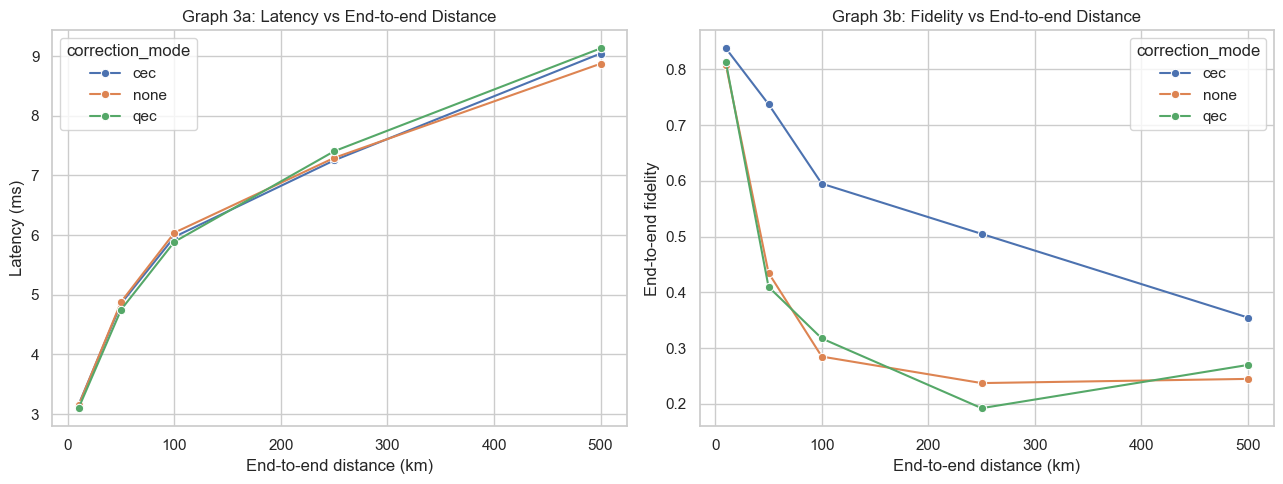

In [ ]:
graph3_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph3_distance_sweep")
graph3_df = load_runner_logs(graph3_log_dir)

if run_after is not None and not graph3_df.empty:
    graph3_df = graph3_df[graph3_df["log_mtime"] >= run_after.timestamp()]

if graph3_df.empty:
    print("No Graph 3 data found.")
else:
    graph3_summary = graph3_df.groupby(["total_distance_km", "correction_mode"], as_index=False).agg(
        mean_fidelity=("fidelity", "mean"),
        mean_latency_ms=("latency_ms", "mean"),
    ).sort_values(["total_distance_km", "correction_mode"]).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.lineplot(data=graph3_summary, x="total_distance_km", y="mean_latency_ms", hue="correction_mode", marker="o", ax=axes[0])
    axes[0].set_xlabel("End-to-end distance (km)")
    axes[0].set_ylabel("Latency (ms)")
    axes[0].set_title("Graph 3a: Latency vs End-to-end Distance")

    sns.lineplot(data=graph3_summary, x="total_distance_km", y="mean_fidelity", hue="correction_mode", marker="o", ax=axes[1])
    axes[1].set_xlabel("End-to-end distance (km)")
    axes[1].set_ylabel("End-to-end fidelity")
    axes[1].set_title("Graph 3b: Fidelity vs End-to-end Distance")

    plt.tight_layout()
    plt.savefig(output_dir / "graph3.png", dpi=300, bbox_inches="tight")
    plt.show()


## Graph 4: Link-Count Sweep

Plot end-to-end fidelity versus number of links, with `10 km` elementary links.


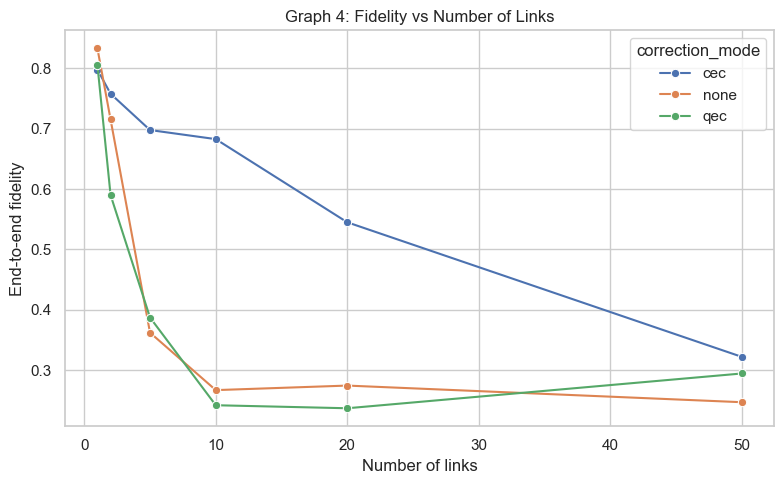

In [ ]:
graph4_log_dir = Path("/Users/patange/Documents/Argonne/QEC/log/runner/graph4_link_count_sweep")
graph4_df = load_runner_logs(graph4_log_dir)

if run_after is not None and not graph4_df.empty:
    graph4_df = graph4_df[graph4_df["log_mtime"] >= run_after.timestamp()]

if graph4_df.empty:
    print("No Graph 4 data found.")
else:
    graph4_summary = graph4_df.groupby(["num_links", "correction_mode"], as_index=False).agg(
        mean_fidelity=("fidelity", "mean"),
    ).sort_values(["num_links", "correction_mode"]).reset_index(drop=True)

    plt.figure(figsize=(8, 5))
    sns.lineplot(data=graph4_summary, x="num_links", y="mean_fidelity", hue="correction_mode", marker="o")
    plt.xlabel("Number of links")
    plt.ylabel("End-to-end fidelity")
    plt.title("Graph 4: Fidelity vs Number of Links")
    plt.tight_layout()
    plt.savefig(output_dir / "graph4.png", dpi=300, bbox_inches="tight")
    plt.show()
